In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('salesdata.csv')
df.head()

,Order_ID,Order_Date,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount_%,Total_Sales
0,ORD001,2025-01-01,Surya,Bangalore,Furniture,Chair,2,3500,0,7000
1,ORD002,2025-01-02,Karthik,Delhi,Furniture,Chair,8,3500,15,28000
2,ORD003,2025-01-03,Meena,Delhi,Clothing,Jeans,10,1800,15,18000
3,ORD004,2025-01-04,Arjun,Delhi,Furniture,Table,4,9000,15,36000
4,ORD005,2025-01-05,Karthik,Chennai,Clothing,T-Shirt,4,700,10,2800


In [ ]:
df.info()
df.isnull().sum()
df.duplicated().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       100 non-null    object
 1   Order_Date     100 non-null    object
 2   Customer_Name  100 non-null    object
 3   City           100 non-null    object
 4   Category       100 non-null    object
 5   Product        100 non-null    object
 6   Quantity       100 non-null    int64 
 7   Unit_Price     100 non-null    int64 
 8   Discount_%     100 non-null    int64 
 9   Total_Sales    100 non-null    int64 
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


np.int64(0)

In [ ]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])
df['Month']=df['Order_Date'].dt.month_name()
df['Year']=df['Order_Date'].dt.year
df.head()

,Order_ID,Order_Date,Customer_Name,City,Category,Product,Quantity,Unit_Price,Discount_%,Total_Sales,Month,Year
0,ORD001,2025-01-01,Surya,Bangalore,Furniture,Chair,2,3500,0,7000,January,2025
1,ORD002,2025-01-02,Karthik,Delhi,Furniture,Chair,8,3500,15,28000,January,2025
2,ORD003,2025-01-03,Meena,Delhi,Clothing,Jeans,10,1800,15,18000,January,2025
3,ORD004,2025-01-04,Arjun,Delhi,Furniture,Table,4,9000,15,36000,January,2025
4,ORD005,2025-01-05,Karthik,Chennai,Clothing,T-Shirt,4,700,10,2800,January,2025


In [ ]:
df.columns=df.columns.str.strip()

In [ ]:
sales_by_category=df.groupby('Category')['Total_Sales'].sum()
print(sales_by_category)

Category
Clothing        343700
Electronics    3167000
Furniture      2785500
Name: Total_Sales, dtype: int64


In [ ]:
top_products=df.groupby('Product')['Total_Sales'].sum().sort_values(ascending=False).head(5)
print(top_products)

Product
Laptop        2145000
Sofa          2044000
Smartphone     792000
Table          423000
Chair          318500
Name: Total_Sales, dtype: int64


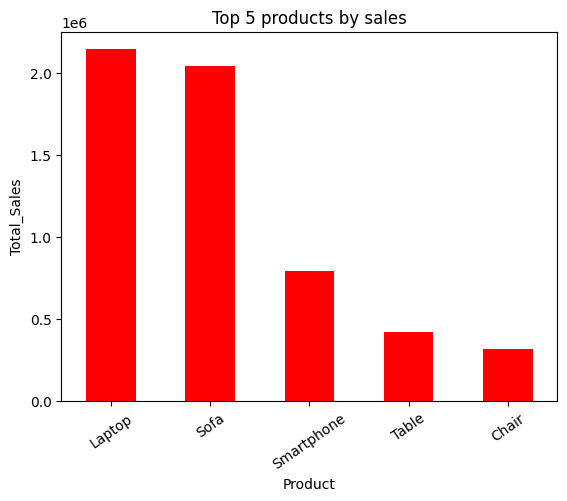

In [ ]:
top_products.plot(kind='bar',color='red')
plt.title('Top 5 products by sales')
plt.xlabel('Product')
plt.ylabel('Total_Sales')
plt.xticks(rotation=35)
plt.show()

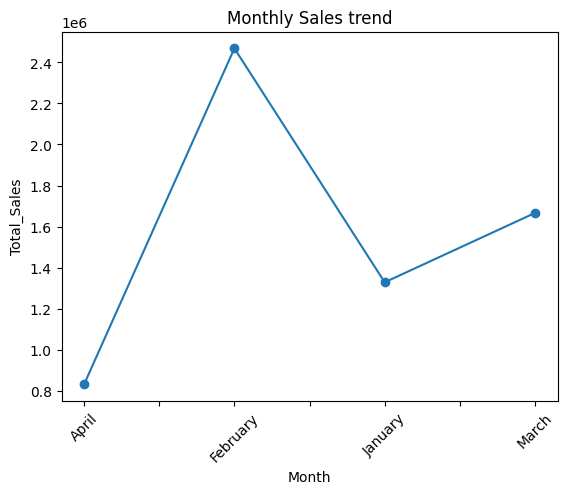

In [ ]:
monthly_sales=df.groupby('Month')['Total_Sales'].sum()
monthly_sales.plot(kind='line',marker='o')
plt.title('Monthly Sales trend')
plt.xlabel('Month')
plt.ylabel('Total_Sales')
plt.xticks(rotation=45)
plt.show()

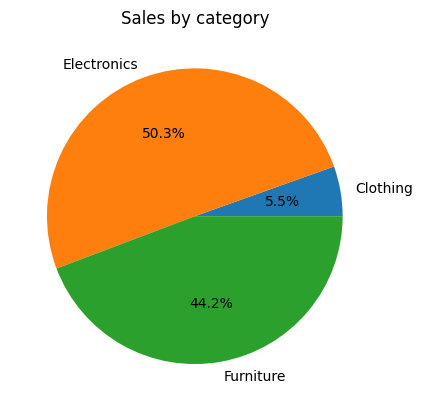

In [ ]:
sales_by_category=df.groupby('Category')['Total_Sales'].sum()
sales_by_category.plot(kind='pie',autopct='%1.1f%%')
plt.title('Sales by category')
plt.ylabel('')
plt.show()